In [1]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import liana as li
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from shapely.geometry import Polygon
import ipympl 
%matplotlib widget
import matplotlib
import spatialdata as spd



/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/janzules/miniforge3/envs/spatial_cpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Data Prep

In [3]:
# Directories
project_dir = Path("/Users/janzules/Roselab/Spatial/CAR_T")
data_dir    = project_dir / "data"
results_dir = project_dir / "results"
figures_dir = project_dir / "figures"

In [4]:
project_dir.exists()

True

In [5]:
# Files
hallmark_file  = project_dir / "code/references/Mouse_Hallmark.gmt"
zarr_file      = data_dir / "zarrFiles/CellCharterClusters"

## Loading Data

In [7]:
#Reading in files

sdata = spd.read_zarr(zarr_file)
adata = sdata.tables['segmentation_counts']


root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2645, 2706)
 - chunks =  ['3', '2645', '2706']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2348, 2448)
 - chunks =  ['3', '2348', '2448']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2445, 2505)
 - chunks =  ['3', '2445', '2505']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero

In [ ]:
# Uploading the hallmark pathways

pathway = {} #
min_genes = 3
max_genes = 5000

with open(hallmark_file, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip("\n").split("\t")
        if len(parts) < 3:
            continue
        name = parts[0].replace("HALLMARK_", "").lower().capitalize()
        genes = [g for g in parts[2:] if g]  # parts[1] is "description"
        if min_genes <= len(genes) <= max_genes:
            pathway[name] = genes
    



# Functions

In [17]:
def read_gmt(gmt_path, min_genes=3, max_genes=5000):
    pathways = {}
    with open(gmt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name = parts[0].replace("HALLMARK_", "").lower().capitalize()
            genes = [g for g in parts[2:] if g]  # parts[1] is "description"
            if min_genes <= len(genes) <= max_genes:
                pathways[name] = genes
    return pathways

# Scoring Pathways of interest

def pathway_scoring(adata, hallmark_file, pathways_of_interest):
    pathways = read_gmt(hallmark_file)
    
    # Checking if I named the pathways correctly
    failed_pathways = []
    for pathway_name in pathways_of_interest:
        if pathway_name not in pathways:
            print(f"Warning: Pathway '{pathway_name}' not found in the provided pathways.")
            failed_pathways.append(pathway_name)
            continue
    
        #Scoring pathways
        genes = pathways[pathway_name]
        
        genes_in_data = [gene for gene in genes if gene in adata.var_names]
        if len(genes_in_data) < 10: # the lowest number of genes in these pathways is around 27
            print(f"Warning: Not enough genes from pathway '{pathway_name}' are present in the data for scoring.")
            failed_pathways.append(pathway_name)
            continue
        
        sc.tl.score_genes(adata, 
                          gene_list=genes_in_data, 
                          score_name=pathway_name)
        if failed_pathways:
            print(f"Failed to score the following pathways: {', '.join(failed_pathways)}")
        
        print(f"Successfully scored pathway: {pathway_name}")

def find_pathway_names(pathways, search_term: list):
    matches = [key for key in pathways.keys() if any(term.lower() in key.lower() for term in search_term)]
    return matches




# Scoring

In [18]:
pathways = ['Glycolysis', 'Interferon_alpha_response', 'Interferon_gamma_response']

pathway_scoring(adata, hallmark_file, pathways_of_interest=pathways)

Successfully scored pathway: Glycolysis
Successfully scored pathway: Interferon_alpha_response
Successfully scored pathway: Interferon_gamma_response


# testing

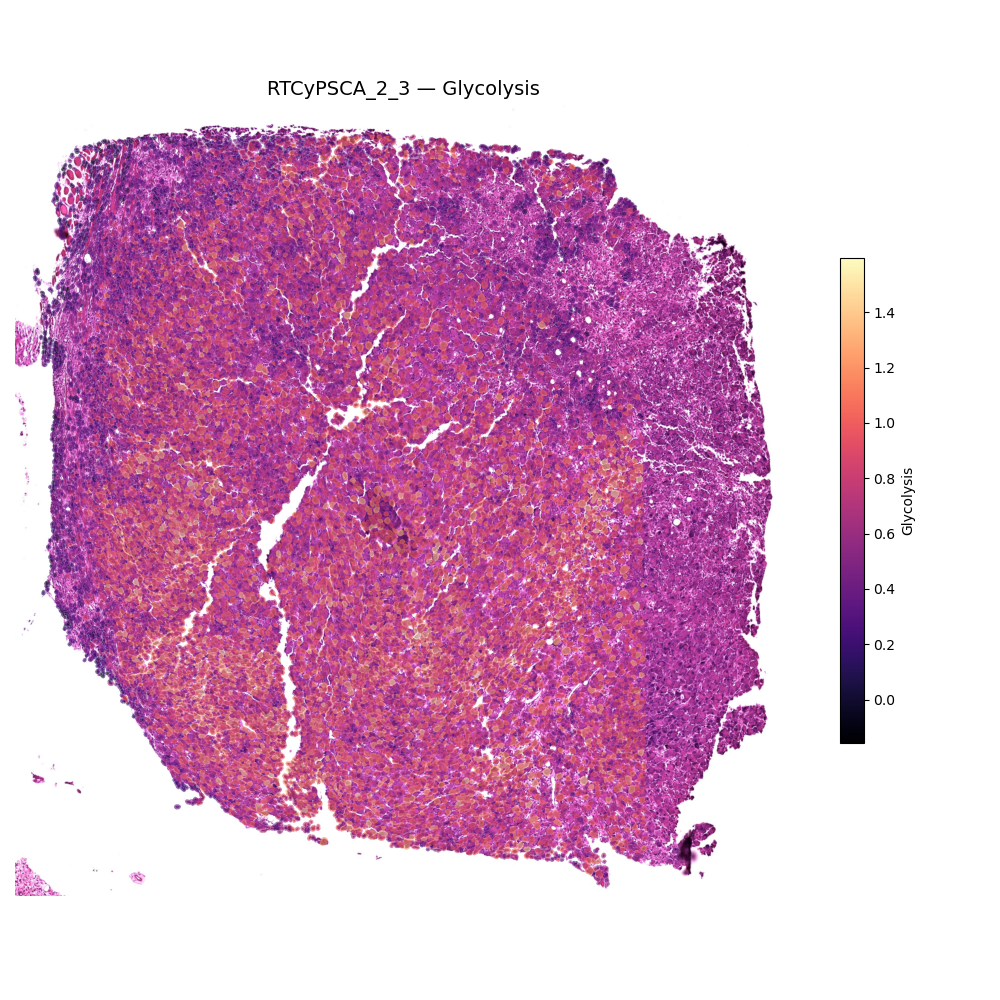

In [20]:
from spatialdata.transformations import get_transformation
from shapely.affinity import scale as shapely_scale, translate
import geopandas as gpd

tissue_name   = "RTCyPSCA_2_3"
pathway_score = "Glycolysis"
cmap          = "magma"

image_key    = f"{tissue_name}_hires_tissue_image"
boundary_key = f"{tissue_name}_cell_boundaries"

image  = sdata.images[image_key].values  # (3, Y, X)
shapes = sdata.shapes[boundary_key].copy()


In [ ]:
def get_tissue_transform(sdata, tissue_name):
    """Returns (scale, tx, ty) for this tissue's shapes → image mapping."""
    shapes_key = f"{tissue_name}_cell_boundaries"
    tf = get_transformation(sdata.shapes[shapes_key], get_all=True)
    # tf is dict: coord_system -> transform object
    cs = "downscale_to_hires"
    t = tf[cs]
    scale = float(t.scale[0])         # uniform scale
    tx, ty = float(t.translation[0]), float(t.translation[1])
    return scale, tx, ty

In [29]:
a = get_transformation(sdata.shapes[boundary_key], get_all=True)

In [36]:
a['downscale_to_hires'].keys()


AttributeError: 'Scale' object has no attribute 'keys'

In [ ]:

# --- Scale factor and translation from the transforms ---
scale_factor = 0.6917224
ty, tx       = 362.0, 2854.0   # translation in y, x

# --- Apply scale to polygons ---
shapes["geometry"] = shapes["geometry"].apply(
    lambda geom: shapely_scale(geom, xfact=scale_factor, yfact=scale_factor, origin=(0, 0))
)

# --- Merge scores ---
mask  = adata.obs['tissue'] == tissue_name
a_sub = adata[mask]
shapes = shapes.join(a_sub.obs[[pathway_score]], how="left")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

img_rgb = np.transpose(image, (1, 2, 0))

# Use extent to place image correctly accounting for translation
h, w = img_rgb.shape[:2]
ax.imshow(img_rgb, extent=[tx, tx + w, ty + h, ty], origin="upper")

shapes.plot(
    column=pathway_score,
    cmap=cmap,
    ax=ax,
    alpha=0.6,
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend_kwds={"label": pathway_score, "shrink": 0.5}
)

ax.set_title(f"{tissue_name} — {pathway_score}", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [92]:
from spatialdata.transformations import get_transformation

# Check what transforms are stored
print(get_transformation(sdata.images[image_key], get_all=True))
print(get_transformation(sdata.shapes[boundary_key], get_all=True))

{'downscale_to_hires': Sequence 
    Translation (c, y, x)
        [   0.  362. 2854.]
    Identity }
{'downscale_to_hires': Scale (x, y)
    [0.6917224 0.6917224]}


In [74]:
a_sub.shape

(19116, 19026)

In [75]:
shapes.shape

(19117, 2)

In [73]:
len(shapes)

19117

In [66]:
scores

array([1.1165798 , 1.16541748, 0.40851565, ..., 0.81602441, 0.46153573,
       0.8713421 ], shape=(19116,))

In [62]:
def plot_pathway_on_tissue(sdata, adata, tissue_name, pathway_score, cmap="magma"):
    """
    tissue_name   : e.g. 'RTCyPSCA_2_3'
    pathway_score : column name in adata.obs, e.g. 'Glycolysis'
    """
    # --- Pull image and shapes ---
    image_key    = f"{tissue_name}_hires_tissue_image"
    boundary_key = f"{tissue_name}_cell_boundaries"

    image    = sdata.images[image_key].values        # shape: (3, Y, X)
    shapes   = sdata.shapes[boundary_key]            # GeoDataFrame

    # --- Subset adata to this tissue ---
    mask   = adata.obs['tissue'] == tissue_name
    a_sub  = adata[mask]
    scores = a_sub.obs[pathway_score].values

    # --- Merge scores into shapes (assuming index alignment) ---
    shapes = shapes.copy()
    shapes[pathway_score] = scores

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 10))

    # HnE image — transpose from (c, y, x) to (y, x, c)
    img_rgb = np.transpose(image, (1, 2, 0))
    ax.imshow(img_rgb, origin="upper")

    # Polygons colored by pathway score
    shapes.plot(
        column=pathway_score,
        cmap=cmap,
        ax=ax,
        alpha=0.6,
        legend=True,
        legend_kwds={"label": pathway_score, "shrink": 0.5}
    )

    ax.set_title(f"{tissue_name} — {pathway_score}", fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Usage
plot_pathway_on_tissue(sdata, adata, 
                       tissue_name="RTCyPSCA_2_3", 
                       pathway_score="Glycolysis")

ValueError: Length of values (19116) does not match length of index (19117)

In [60]:
print(sdata.shapes['RTCyPSCA_2_3_cell_boundaries'].head())
print(adata[adata.obs['tissue'] == 'RTCyPSCA_2_3'].obs.head())

                                             cell_id  \
F08543_cellid_000006548-1  F08543_cellid_000006548-1   
F08543_cellid_000006549-1  F08543_cellid_000006549-1   
F08543_cellid_000006550-1  F08543_cellid_000006550-1   
F08543_cellid_000006551-1  F08543_cellid_000006551-1   
F08543_cellid_000006552-1  F08543_cellid_000006552-1   

                                                                    geometry  
F08543_cellid_000006548-1  POLYGON ((5799.1 3135.8, 5799.1 3133.9, 5793.3...  
F08543_cellid_000006549-1  POLYGON ((5358.7 2705.7, 5358.6 2703.8, 5354.8...  
F08543_cellid_000006550-1  POLYGON ((4823.5 1305.1, 4823.4 1299.3, 4821.5...  
F08543_cellid_000006551-1  POLYGON ((4622.2 3556.3, 4622.2 3554.3, 4620.2...  
F08543_cellid_000006552-1  POLYGON ((5255.2 1027.5, 5255.2 1025.6, 5253.2...  
                           sample                    cell_id  \
F08543_cellid_000006548-1  F08543  F08543_cellid_000006548-1   
F08543_cellid_000006549-1  F08543  F08543_cellid_000006549-1 

In [82]:
missing = set(shapes.index) - set(a_sub.obs.index)

print(f"Missing indices in shapes: {missing}")

Missing indices in shapes: {'F08543_cellid_000014853-1'}


# Pathway spatial visualization

In [52]:
adata.obs.iloc[:5, 20:]

,X_cc_01,X_cc_012,X_cc_2,Glycolysis,Interferon_alpha_response
F07839_cellid_000000001-1,6,2,6,0.470333,0.527505
F07839_cellid_000000002-1,6,2,6,0.467678,0.574010
F07839_cellid_000000004-1,0,1,4,0.251500,1.023255
F07839_cellid_000000005-1,0,1,4,0.382019,2.250942
F07839_cellid_000000006-1,6,2,6,0.537769,0.360079


## Codex

# Older code

In [ ]:
# # Info
# whatFer = "one" # "one" or  "two"

# #Load data
# #So .X is log1p(CP1e6) (CPM-style per-million normalization, then log1p)
# base_folder = Path(f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/{whatFer}fer/")
# adata_file = base_folder / f"{whatFer}fer.h5ad"
# # out_figs = base_folder / "figures"
# # out_figs = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/")

# ST_sample = sc.read_h5ad(adata_file)

## Library selection

In [6]:
sample_name = "RTCyPSCA_1_4"
# sample_name = 

lib_id = "F07839"
adata = ST_sample[ST_sample.obs['mouse']=="RTCyPSCA_1_4"].copy()

## Merging polygons

In [7]:
# Load nuclei polygons
segmentation_path = Path("/mnt/c/Users/jonan/Documents/1Work/Roselab/Spatial/CAR_T/data/cell_segmentation/")
gdf_file = segmentation_path / "concatenated" / "combined_nuclei_geometry.gpkg"
gdf = gpd.read_file(gdf_file)


ERROR 1: PROJ: proj_create_from_database: Open of /home/jon/anaconda3/envs/spatial_analysis_env/share/proj failed


# Visualizing selection - spp1-cd44

In [8]:
li.ut.spatial_neighbors(adata, bandwidth=40, cutoff = 0.1, kernel='gaussian', set_diag=True)
lr = li.mt.bivariate(adata,
                resource_name='mouseconsensus', # NOTE: uses HUMAN gene symbols!
                local_name='cosine', # Name of the function
                global_name="morans", # Name global function
                n_perms=100, # Number of permutations to calculate a p-value
                mask_negatives=False, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.05, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=False
                )

/home/jon/anaconda3/envs/spatial_analysis_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


In [9]:
# gdf_file = segmentation_path /  "concatenated" / "combined_nuclei_geometry.gpkg"
# geo_file = gpd.read_file(gdf_file)

# gdf = geo.merge(ST_sample.obs[['id', 'n_counts']], on='id', how='inner')

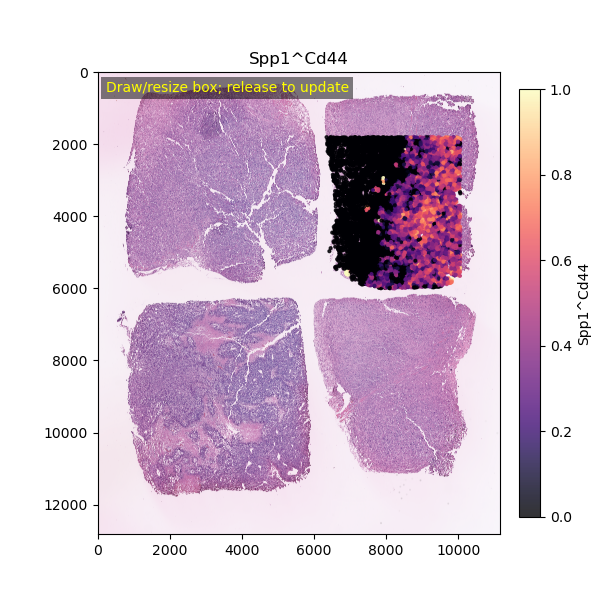

In [10]:
%matplotlib widget
import numpy as np, matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import scipy.sparse as sp

pair = "Spp1^Cd44"
lib = "F07839"
img = ST_sample.uns["spatial"][lib]["images"]["hires"]   # full-res HxW[×3]
H, W = img.shape[:2]

# --- data (full-res pixel coords) ---
coords = np.asarray(lr.obsm["spatial"])                  # (n,2) in full-res pixels
vals   = lr[:, pair].X
vals   = vals.toarray().ravel() if sp.issparse(vals) else np.asarray(vals).ravel()

# --- plot image + points in the SAME coordinate system ---
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img, origin="upper", extent=(0, W, H, 0))      # <- crucial: sets data coords = pixels #Q - What's curcial about this?
sc = ax.scatter(coords[:,0], coords[:,1], c=vals, s=4, cmap="magma", alpha=0.8)
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=pair)
ax.set_xlim(0, W); ax.set_ylim(H, 0)                     # y downward like pixels
ax.set_title(pair)

# add once, after ax.set_title(...)
status = ax.text(
    0.02, 0.98, "Draw/resize box; release to update",
    transform=ax.transAxes, va="top", ha="left",
    color="yellow", bbox=dict(facecolor="black", alpha=0.5, pad=3, edgecolor="none")
)


def onselect(eclick, erelease):
    if None in (eclick.xdata, eclick.ydata, erelease.xdata, erelease.ydata):
        status.set_text("Selection cancelled (drag fully inside axes)"); fig.canvas.draw_idle(); return
    x0, x1 = sorted([eclick.xdata,  erelease.xdata])
    y0, y1 = sorted([eclick.ydata,  erelease.ydata])
    sel = (coords[:,0] >= x0) & (coords[:,0] <= x1) & (coords[:,1] >= y0) & (coords[:,1] <= y1)
    state["sel"][:] = sel
    status.set_text(f"Picked: {sel.sum()} cells")
    fig.canvas.draw_idle()

# optional: press Enter to finalize (turn box green & freeze)
def on_key(event):
    if event.key in ("enter","return"):
        rect.set_active(False)
        try: rect.to_draw.set_edgecolor("lime")
        except: pass
        status.set_text(f"Final: {state['sel'].sum()} cells"); fig.canvas.draw_idle()

state = {"sel": np.zeros(coords.shape[0], dtype=bool)}

# make sure pan/zoom isn’t active (ipympl toolbar)
tb = getattr(fig.canvas, "toolbar", None)
if tb is not None:
    tb.mode = ""   # deactivate zoom/pan so events reach the selector

# keep a reference in a global / outer-scope var so it doesn't get GC'd
rect = RectangleSelector(
    ax, onselect,
    button=[1],                 # left mouse
    interactive=True,           # allow resize/move
    useblit=False,              # safer with %matplotlib widget
    drag_from_anywhere=True,    # easier to adjust
    props=dict(edgecolor="yellow", facecolor="none", linewidth=2, alpha=0.9)
)

# optional: start with a small visible box
# rect.extents = (W*0.25, W*0.55, H*0.35, H*0.65)

# finalize on Enter
cid_key = fig.canvas.mpl_connect("key_press_event", on_key)


In [11]:
# After you draw/adjust the yellow box and release the mouse:
mask = state["sel"].copy()
print("Selected:", mask.sum(), "/", len(mask))

selected_ids = lr.obs.index[mask]
print("First few IDs:", selected_ids[:10].tolist())

# optional: subset objects for downstream plots
lr_sel = lr[mask].copy()
adata_sel = ST_sample[ST_sample.obs.index.isin(selected_ids)].copy()


Selected: 3581 / 12667
First few IDs: ['ID_25781', 'ID_25787', 'ID_25791', 'ID_25798', 'ID_25809', 'ID_25812', 'ID_25815', 'ID_25826', 'ID_25831', 'ID_25837']


## Beginning Scoring module

In [12]:
import pandas as pd

# Path to your CSV of curated sets
CtxPathway = "/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/docs/research/Selected_pathways.csv"

# Load & tidy
pth = pd.read_csv(CtxPathway, sep=None, engine="python")
assert {"set_name","genes"}.issubset(pth.columns), pth.columns

# turn the semicolon lists into Python lists
pth["gene_list"] = pth["genes"].astype(str).str.split(r";\s*")

# ---- choose one or many sets here ----
# For now: just the granzyme-mediated pathway (you can add more in the list)
chosen_sets = [
    "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY",
    # "GOBP_NATURAL_KILLER_CELL_DEGRANULATION",
    # "GOBP_TRAIL_ACTIVATED_APOPTOTIC_SIGNALING_PATHWAY",
]

# Build dict: set_name -> list of genes
set2genes = {
    row.set_name: row.gene_list
    for _, row in pth[pth["set_name"].isin(chosen_sets)].iterrows()
}

print("Selected pathways:", list(set2genes.keys()))
for k, gl in set2genes.items():
    print(f"  {k}: {len(gl)} genes (from CSV)")


Selected pathways: ['GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY']
  GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY: 13 genes (from CSV)


In [13]:
import numpy as np

# case-insensitive map for gene matching
vmap = {g.lower(): g for g in ST_sample.var_names}
def match_genes(glist):
    q = [g.lower() for g in glist]
    kept    = [vmap[g] for g in q if g in vmap]
    missing = [g for g in glist if g.lower() not in vmap]
    return kept, missing

matched = {}
for setname, glist in set2genes.items():
    kept, missing = match_genes(glist)
    matched[setname] = kept
    print(f"\n[{setname}] kept={len(kept)}  missing={len(missing)}")
    if missing:
        print("  Missing:", missing)

# safety check
total_kept = sum(len(v) for v in matched.values())
assert total_kept > 0, "No genes from chosen pathways were found in ST_sample.var_names."



[GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY] kept=12  missing=1
  Missing: ['Gsdme']


In [46]:
import scanpy as sc

# Use a raw-ish layer if you keep counts there; otherwise .X
# If you want to force a particular layer: sc.pp.normalize_total(...) before scoring, or set `use_raw=True`.
use_raw = False

for setname, glist in matched.items():
    score_col = f"{setname}__score"
    sc.tl.score_genes(
        ST_sample,
        glist,
        score_name=score_col,
        use_raw=use_raw,     # False = use .X; True = use .raw
        ctrl_size=50,        # Seurat-like background correction
        copy=False
    )
    print(f"Scored: {score_col} (head) ->", ST_sample.obs[score_col].head().round(3).tolist()[:5])

Scored: GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score (head) -> [0.436, -0.025, 0.395, 0.0, 1.302]


In [47]:
# Choose which score column to visualize now
score_col = "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score"

# align to lr.obs order
score_all = ST_sample.obs.loc[lr.obs.index, score_col].to_numpy()

# --- thresholds (quantiles) computed inside your rectangular selection ---
sel = mask.copy()                   # from your selector
vals_sel   = vals[sel]              # interaction values inside selection
score_sel  = score_all[sel]

# interaction high threshold (same p as you used; adjust as you like)
pct_int   = 0.45
thr_int   = np.quantile(vals_sel, pct_int) if sel.any() else np.quantile(vals, pct_int)

# module-score high threshold (use top 40% by default for visibility)
pct_score = 0.60
thr_score = np.quantile(score_sel, pct_score) if sel.any() else np.quantile(score_all, pct_score)

int_high  = vals >=  thr_int
score_hi  = score_all > thr_score

# categories (priority to interaction)
INT_HIGH  = sel & int_high
GENE_ONLY = sel & (~int_high) & score_hi
OTHER     = sel & (~int_high) & (~score_hi)

print(f"Thresholds -> INT thr={thr_int:.3g} (p{int(pct_int*100)}), SCORE thr={thr_score:.3g} (p{int(pct_score*100)})")
print(f"Counts in selection -> INT_HIGH={INT_HIGH.sum()}, GENE_ONLY={GENE_ONLY.sum()}, OTHER={OTHER.sum()}")


Thresholds -> INT thr=0.305 (p45), SCORE thr=-0.0481 (p60)
Counts in selection -> INT_HIGH=2221, GENE_ONLY=816, OTHER=1002


In [48]:
from shapely.affinity import translate
import pandas as pd
import numpy as np

coords_all = np.asarray(lr.obsm["spatial"])
coords_sel = coords_all[sel]
pad = 100
xmin = max(0, int(np.floor(coords_sel[:,0].min()) - pad))
xmax = min(W, int(np.ceil (coords_sel[:,0].max()) + pad))
ymin = max(0, int(np.floor(coords_sel[:,1].min()) - pad))
ymax = min(H, int(np.ceil (coords_sel[:,1].max()) + pad))

img_crop = img[ymin:ymax, xmin:xmax]
h, w = img_crop.shape[:2]

def adj(mask_):
    c = coords_all[mask_].copy()
    c[:,0] -= xmin; c[:,1] -= ymin
    return c

# polygon table
if "id" not in gdf.columns:
    gdf = gdf.reset_index().rename(columns={"index":"id"})

sel_ids = lr.obs.index[sel]
gdf_sel = gdf[gdf["id"].isin(sel_ids)].copy()

# build category labels (INT_HIGH takes priority)
cat = np.full(lr.shape[0], "OTHER", dtype=object)
cat[GENE_ONLY] = "GENE_ONLY"
cat[INT_HIGH]  = "INT_HIGH"
gdf_sel["category"] = gdf_sel["id"].map(pd.Series(cat, index=lr.obs.index))

# translate polygons into crop frame
gdf_sel["geometry"] = gdf_sel["geometry"].apply(lambda geom: translate(geom, xoff=-xmin, yoff=-ymin))

# attach both continuous attributes
val_map   = pd.Series(vals,      index=lr.obs.index)  # interaction value
score_map = pd.Series(score_all, index=lr.obs.index)  # module score
gdf_sel["int_val"]   = gdf_sel["id"].map(val_map)
gdf_sel["score_val"] = gdf_sel["id"].map(score_map)

print("Polygon counts:", gdf_sel["category"].value_counts().to_dict())


Polygon counts: {'INT_HIGH': 2221, 'OTHER': 1002, 'GENE_ONLY': 816}


## Gradient plot

/tmp/ipykernel_22462/3153971416.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
/tmp/ipykernel_22462/3153971416.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
/tmp/ipykernel_22462/3153971416.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


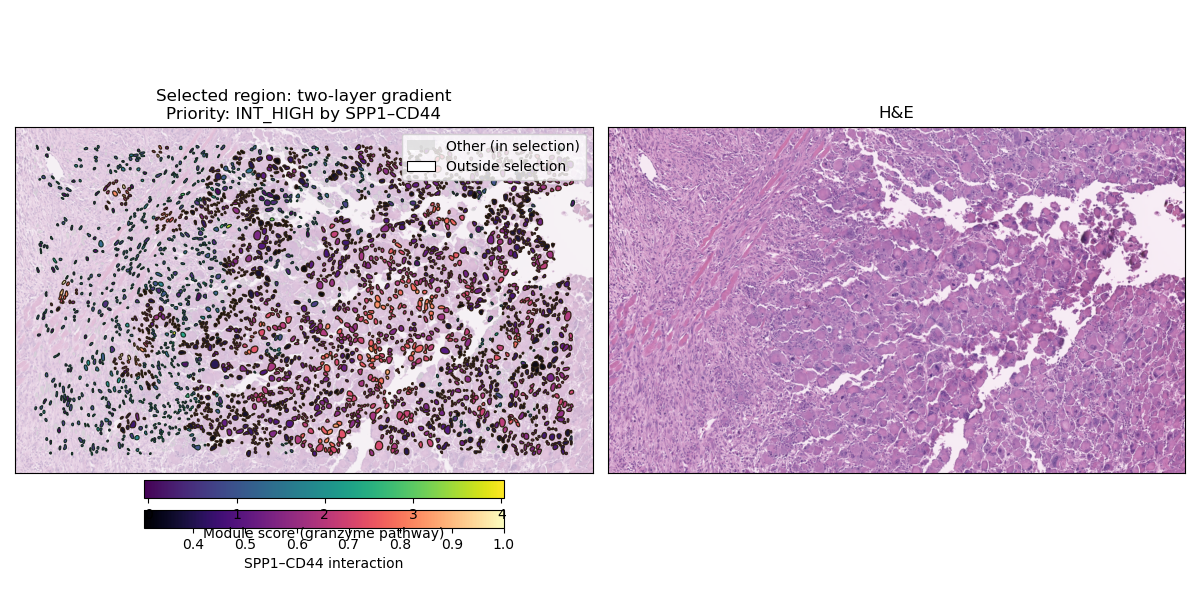

In [50]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.patches import Patch

# colormaps & norms per layer
v_int   = gdf_sel.loc[gdf_sel["category"]=="INT_HIGH",  "int_val"].to_numpy()
v_score = gdf_sel.loc[gdf_sel["category"]=="GENE_ONLY", "score_val"].to_numpy()

# robust fallbacks if an empty category occurs
vmin_int,   vmax_int   = (float(np.nanmin(v_int)),   float(np.nanmax(v_int)))   if v_int.size   else (0.0, 1.0)
vmin_score, vmax_score = (float(np.nanmin(v_score)), float(np.nanmax(v_score))) if v_score.size else (0.0, 1.0)

norm_int   = Normalize(vmin=vmin_int,   vmax=vmax_int)
norm_score = Normalize(vmin=vmin_score, vmax=vmax_score)

cmap_int   = cm.get_cmap("magma")   # interaction
cmap_score = cm.get_cmap("viridis") # module score (contrasts well)

fig, (axL, axR) = plt.subplots(ncols=2, figsize=(12,6))

# H&E knobs (left pane altered, right pane raw)
he_alpha_left      = 0.5
he_brightness_left = 0.95
he_gamma_left      = 0.85

imgL = img_crop.astype(np.float32) / 255.0
imgL = np.clip(imgL * he_brightness_left, 0.0, 1.0)
if he_gamma_left != 1.0:
    imgL = np.clip(imgL ** he_gamma_left, 0.0, 1.0)

axL.imshow(imgL, origin="upper", extent=(0, w, h, 0), alpha=he_alpha_left)
axL.set_xlim(0, w); axL.set_ylim(h, 0)

axR.imshow(img_crop, origin="upper", extent=(0, w, h, 0))
axR.set_xlim(0, w); axR.set_ylim(h, 0)

# --- OTHER (neutral background polygons) ---
sub = gdf_sel[gdf_sel["category"]=="OTHER"]
if not sub.empty:
    sub.plot(ax=axL, facecolor="#d9d9d9", edgecolor="none", linewidth=0.3, alpha=0.7, zorder=1)

# --- GENE_ONLY (module score gradient) ---
sub = gdf_sel[gdf_sel["category"]=="GENE_ONLY"]
if not sub.empty:
    sub.plot(ax=axL, column="score_val", cmap=cmap_score, linewidth=0.8, edgecolor="#0f2a1b",
             alpha=0.95, zorder=2, legend=False)

# --- INT_HIGH (interaction gradient) ---
sub = gdf_sel[gdf_sel["category"]=="INT_HIGH"]
if not sub.empty:
    sub.plot(ax=axL, column="int_val", cmap=cmap_int, linewidth=0.9, edgecolor="#2b1d0e",
             alpha=0.95, zorder=3, legend=False)

# Remove existing colorbars in fig (useful when re-running)
for a in list(fig.axes):
    try:
        if a.get_label() == '<colorbar>':
            a.remove()
    except Exception:
        pass

# Two separate colorbars (left axis)
m_int   = cm.ScalarMappable(norm=norm_int,   cmap=cmap_int);   m_int.set_array([])
m_score = cm.ScalarMappable(norm=norm_score, cmap=cmap_score); m_score.set_array([])

# stack colorbars vertically on the left
cax1 = fig.add_axes([0.12, 0.12, 0.30, 0.03])  # [left,bottom,width,height]
cax2 = fig.add_axes([0.12, 0.17, 0.30, 0.03])

cbar_score = fig.colorbar(m_score, cax=cax2, orientation="horizontal")
cbar_score.set_label("Module score (granzyme pathway)")

cbar_int = fig.colorbar(m_int, cax=cax1, orientation="horizontal")
cbar_int.set_label("SPP1–CD44 interaction")

# Titles + legend
axL.set_title("Selected region: two-layer gradient\nPriority: INT_HIGH by SPP1–CD44")
axR.set_title("H&E")

handles = [
    Patch(facecolor="#d9d9d9", edgecolor="none", alpha=0.7, label="Other (in selection)"),
    Patch(facecolor="white",   edgecolor="black", linewidth=0.8, label="Outside selection")
]
axL.legend(handles=handles, loc="upper right", frameon=True)

for ax in (axL, axR):
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()


In [31]:
# from pathlib import Path
# out_figs = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/")
# out_figs.mkdir(parents=True, exist_ok=True)

# stem = "First_sectioning__GranzymeScore_vs_SPP1_CD44"
# png_path = out_figs / f"{stem}.png"
# fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
# print("Saved:", png_path)


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/First_sectioning__GranzymeScore_vs_SPP1_CD44.png


## Categorizing score ranges

[GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score] n=12667  mean=0.095  sd=0.479
quantiles 5/25/50/75/95%: [-0.409, -0.157, -0.071, 0.339, 0.983]


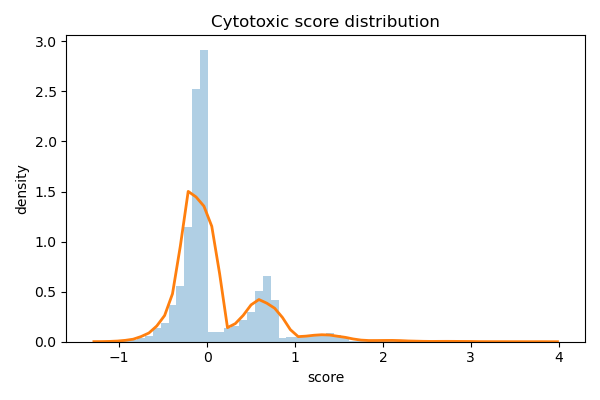

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Pick the score column you computed earlier:
score_col = "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score"

# Align to lr.obs order (so we can mask consistently with your selection)
score_all = ST_sample.obs.loc[lr.obs.index, score_col].to_numpy()

# Basic stats & quantiles
qs = np.quantile(score_all, [0.05, 0.25, 0.5, 0.75, 0.95])
print(f"[{score_col}] n={score_all.size}  mean={score_all.mean():.3f}  sd={score_all.std():.3f}")
print("quantiles 5/25/50/75/95%:", [round(x,3) for x in qs.tolist()])

# Histogram + simple KDE-like curve (via normalized hist bins + rolling mean)
fig, ax = plt.subplots(figsize=(6,4))
n, bins, _ = ax.hist(score_all, bins=60, density=True, alpha=0.35, edgecolor="none")
centers = 0.5*(bins[:-1]+bins[1:])
# quick smooth
window = 5
smooth = np.convolve(n, np.ones(window)/window, mode="same")
ax.plot(centers, smooth, lw=2)

ax.set_title("Cytotoxic score distribution")
ax.set_xlabel("score"); ax.set_ylabel("density"); plt.tight_layout(); 
plt.show()


Chosen thresholds -> MED ≥ 0.300, VHIGH ≥ 0.983


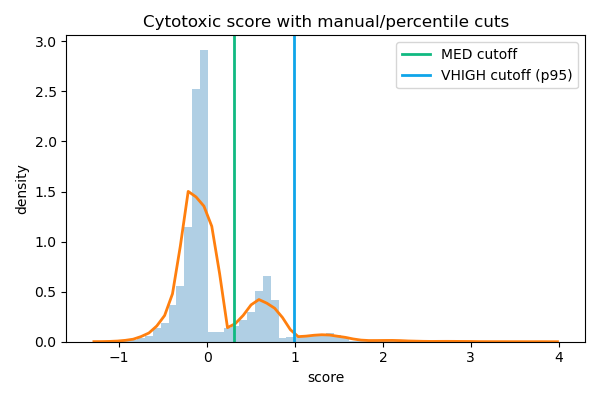

In [73]:
# You already have `score_all` aligned to lr.obs.index
t_med  = 0.30                      # manual valley cut (edit as you like)
t_high = float(np.quantile(score_all, 0.95))   # very high = strict tail

print(f"Chosen thresholds -> MED ≥ {t_med:.3f}, VHIGH ≥ {t_high:.3f}")

# quick check on the histogram
fig, ax = plt.subplots(figsize=(6,4))
n,bins,_ = ax.hist(score_all, bins=60, density=True, alpha=0.35, edgecolor="none")
centers  = 0.5*(bins[:-1]+bins[1:])
ax.plot(centers, np.convolve(n, np.ones(5)/5, mode="same"), lw=2)
ax.axvline(t_med,  color="#10b981", lw=2, label="MED cutoff")
ax.axvline(t_high, color="#0ea5e9", lw=2, label="VHIGH cutoff (p95)")
ax.set_title("Cytotoxic score with manual/percentile cuts"); ax.set_xlabel("score"); ax.set_ylabel("density")
ax.legend(); plt.tight_layout(); #fig


In [54]:
# Interaction high inside selection (reuse your selection mask `sel` and vals)
pct_int = 0.45
thr_int = np.quantile(vals[sel], pct_int) if sel.any() else np.quantile(vals, pct_int)
INT_HIGH   = sel & (vals >= thr_int)

CYTO_VHIGH = sel & (~INT_HIGH) & (score_all >= t_high)
CYTO_MED   = sel & (~INT_HIGH) & (score_all >= t_med) & (score_all < t_high)
OTHER      = sel & (~INT_HIGH) & (score_all <  t_med)

print(f"In selection: INT_HIGH={INT_HIGH.sum()}, CYTO_VHIGH={CYTO_VHIGH.sum()}, CYTO_MED={CYTO_MED.sum()}, OTHER={OTHER.sum()}")


In selection: INT_HIGH=2221, CYTO_VHIGH=117, CYTO_MED=465, OTHER=1236


### Plotting categorical

In [14]:
from shapely.affinity import translate
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.patches import Patch

# --- crop region around selection (same as before) ---
coords_all = np.asarray(lr.obsm["spatial"])
coords_sel = coords_all[sel]
pad = 100
xmin = max(0, int(np.floor(coords_sel[:,0].min()) - pad))
xmax = min(W, int(np.ceil (coords_sel[:,0].max()) + pad))
ymin = max(0, int(np.floor(coords_sel[:,1].min()) - pad))
ymax = min(H, int(np.ceil (coords_sel[:,1].max()) + pad))
img_crop = img[ymin:ymax, xmin:xmax]; h, w = img_crop.shape[:2]

# polygons for selected cells
if "id" not in gdf.columns:
    gdf = gdf.reset_index().rename(columns={"index":"id"})
sel_ids = lr.obs.index[sel]
gdf_sel = gdf[gdf["id"].isin(sel_ids)].copy()

# category map (priority already applied in masks above)
cat = np.full(lr.shape[0], "OTHER", dtype=object)
cat[CYTO_MED]   = "CYTO_MED"
cat[CYTO_VHIGH] = "CYTO_VHIGH"
cat[INT_HIGH]   = "INT_HIGH"
gdf_sel["category"] = gdf_sel["id"].map(pd.Series(cat, index=lr.obs.index))

# shift into the crop frame
gdf_sel["geometry"] = gdf_sel["geometry"].apply(lambda geom: translate(geom, xoff=-xmin, yoff=-ymin))

# attach interaction values for INT_HIGH color-mapping
gdf_sel["int_val"] = gdf_sel["id"].map(pd.Series(vals, index=lr.obs.index))

# colors (colorblind-friendly)
col_other     = "#f5deb3"
col_cyto_med  = "#7dd3fc"  # sky blue
col_cyto_vhi  = "#a3e635"  # lime
edge_cyto_vhi = "#365314"   # darker edge
cmap_int      = cm.get_cmap("magma")

# normalize interaction on INT_HIGH only
v_int = gdf_sel.loc[gdf_sel["category"]=="INT_HIGH","int_val"].to_numpy()
vmin_int, vmax_int = (float(np.nanmin(v_int)), float(np.nanmax(v_int))) if v_int.size else (0.0,1.0)
norm_int = Normalize(vmin=vmin_int, vmax=vmax_int)

# figure
fig, (axL, axR) = plt.subplots(ncols=2, figsize=(12,6))
axL.imshow(img_crop, origin="upper", extent=(0,w,h,0), alpha=0.55)
axR.imshow(img_crop, origin="upper", extent=(0,w,h,0))

# OTHER
sub = gdf_sel[gdf_sel["category"]=="OTHER"]
if not sub.empty:
    sub.plot(ax=axL, facecolor=col_other, edgecolor="none", linewidth=0.3, alpha=0.85, zorder=1)

# CYTO_MED
sub = gdf_sel[gdf_sel["category"]=="CYTO_MED"]
if not sub.empty:
    sub.plot(ax=axL, facecolor=col_cyto_med, edgecolor="#1e3a8a", linewidth=0.6, alpha=0.95, zorder=2)

# CYTO_VHIGH
sub = gdf_sel[gdf_sel["category"]=="CYTO_VHIGH"]
if not sub.empty:
    sub.plot(ax=axL, facecolor=col_cyto_vhi, edgecolor=edge_cyto_vhi, linewidth=0.7, alpha=0.96, zorder=3)

# INT_HIGH gradient
sub = gdf_sel[gdf_sel["category"]=="INT_HIGH"]
if not sub.empty:
    colors = sub["int_val"].map(lambda v: cmap_int(norm_int(v)))
    sub.plot(ax=axL, color=list(colors.values), edgecolor="#2b1d0e", linewidth=0.8, alpha=0.96, zorder=4)

# colorbar for interaction
if v_int.size:
    m_int = cm.ScalarMappable(norm=norm_int, cmap=cmap_int); m_int.set_array([])
    cax = fig.add_axes([0.12, 0.12, 0.30, 0.03])
    cbar = fig.colorbar(m_int, cax=cax, orientation="horizontal")
    cbar.set_label("SPP1–CD44 interaction (INT_HIGH)")

axL.set_title("Spatial distribution of cytotoxic and SPP1–CD44-interacting cells")
axR.set_title("H&E")
for ax in (axL, axR): ax.set_xticks([]); ax.set_yticks([])

legend = [
    Patch(facecolor=col_cyto_vhi, edgecolor=edge_cyto_vhi, label="CYTO_VHIGH (≥ p95)"),
    Patch(facecolor=col_cyto_med, edgecolor="#1e3a8a", label=f"CYTO_MED (≥ {t_med:.2f})"),
    Patch(facecolor=col_other,    edgecolor="none",    label="Other (in selection)")
]
axL.legend(handles=legend, loc="upper right", frameon=True)
plt.tight_layout(); 
plt.show()


NameError: name 'sel' is not defined

In [67]:
from pathlib import Path

# same output folder
out_figs = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/")
out_figs.mkdir(parents=True, exist_ok=True)

# helpful, descriptive file name
stem = f"GranzymeScore_THRESH_med{t_med:.2f}_vhigh{t_high:.2f}__vs_SPP1-CD44"

# save PNG (and optionally PDF/SVG for vector)
fig.savefig(out_figs / f"{stem}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
# fig.savefig(out_figs / f"{stem}.pdf", bbox_inches="tight", pad_inches=0.02)
# fig.savefig(out_figs / f"{stem}.svg", bbox_inches="tight", pad_inches=0.02)

print("Saved:", out_figs / f"{stem}.png")


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/GranzymeScore_THRESH_med0.30_vhigh0.98__vs_SPP1-CD44.png


# Visualizing score distributions

In [81]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# --- score column you already computed ---
score_col = "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score"

# --- all-cell vector (global) ---
scores_all = ST_sample.obs[score_col].to_numpy()

# --- GLOBAL cutoffs (fixed for all plots/tables) ---
t_med  = 0.15                                  # manual valley cut
t_high = float(np.quantile(scores_all, 0.95))  # strict tail

print(f"[GLOBAL] MED ≥ {t_med:.3f}, VHIGH ≥ {t_high:.3f}")

# --- output dirs ---
base_out = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/")
plot_mouse_dir = base_out / "mouse";      plot_mouse_dir.mkdir(parents=True, exist_ok=True)
plot_cond_dir  = base_out / "condition";  plot_cond_dir.mkdir(parents=True, exist_ok=True)

# keep common x-range & bins so panels are comparable
xmin, xmax = float(np.nanmin(scores_all)), float(np.nanmax(scores_all))
bins = np.linspace(xmin, xmax, 60)


[GLOBAL] MED ≥ 0.150, VHIGH ≥ 1.077


## By Mouse

In [82]:
rows_mouse = []
for m in ST_sample.obs["mouse"].dropna().unique():
    s = ST_sample.obs.loc[ST_sample.obs["mouse"]==m, score_col].dropna().to_numpy()
    if s.size == 0: 
        continue

    # quantiles + extras
    qs = np.quantile(s, [0.05,0.25,0.50,0.75,0.95])
    rows_mouse.append(dict(
        mouse=m, n=int(s.size), mean=float(s.mean()), sd=float(s.std()),
        q05=float(qs[0]), q25=float(qs[1]), q50=float(qs[2]), q75=float(qs[3]), q95=float(qs[4]),
        t_med=float(t_med), t_high=float(t_high),
        prop_ge_med=float((s>=t_med).mean()), prop_ge_high=float((s>=t_high).mean())
    ))

    # plot
    fig, ax = plt.subplots(figsize=(6,4))
    n, _, _ = ax.hist(s, bins=bins, density=True, alpha=0.35, edgecolor="none")
    centers = 0.5*(bins[:-1]+bins[1:])
    smooth  = np.convolve(n, np.ones(5)/5, mode="same")
    ax.plot(centers, smooth, lw=2)
    ax.axvline(t_med,  color="#10b981", lw=2, label=f"MED ({t_med:.2f})")
    ax.axvline(t_high, color="#0ea5e9", lw=2, label=f"VHIGH (p95={t_high:.2f})")
    ax.set_title(f"Cytotoxic score • mouse={m}")
    ax.set_xlabel("score"); ax.set_ylabel("density")
    ax.legend(); plt.tight_layout()

    # save
    fig.savefig(plot_mouse_dir / f"cytotoxic_score_hist_mouse-{m}.png",
                dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

# write one CSV for all mice
df_mouse = pd.DataFrame(rows_mouse).sort_values("mouse")
csv_mouse = plot_mouse_dir / "cytotoxic_quantiles_by_mouse.csv"
df_mouse.to_csv(csv_mouse, index=False)
print("Saved mouse CSV ->", csv_mouse)


Saved mouse CSV -> /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/mouse/cytotoxic_quantiles_by_mouse.csv


## By condition

In [83]:
rows_cond = []
for c in ST_sample.obs["condition"].dropna().unique():
    s = ST_sample.obs.loc[ST_sample.obs["condition"]==c, score_col].dropna().to_numpy()
    if s.size == 0:
        continue

    qs = np.quantile(s, [0.05,0.25,0.50,0.75,0.95])
    rows_cond.append(dict(
        condition=c, n=int(s.size), mean=float(s.mean()), sd=float(s.std()),
        q05=float(qs[0]), q25=float(qs[1]), q50=float(qs[2]), q75=float(qs[3]), q95=float(qs[4]),
        t_med=float(t_med), t_high=float(t_high),
        prop_ge_med=float((s>=t_med).mean()), prop_ge_high=float((s>=t_high).mean())
    ))

    fig, ax = plt.subplots(figsize=(6,4))
    n, _, _ = ax.hist(s, bins=bins, density=True, alpha=0.35, edgecolor="none")
    centers = 0.5*(bins[:-1]+bins[1:])
    smooth  = np.convolve(n, np.ones(5)/5, mode="same")
    ax.plot(centers, smooth, lw=2)
    ax.axvline(t_med,  color="#10b981", lw=2, label=f"MED ({t_med:.2f})")
    ax.axvline(t_high, color="#0ea5e9", lw=2, label=f"VHIGH (p95={t_high:.2f})")
    ax.set_title(f"Cytotoxic score • condition={c}")
    ax.set_xlabel("score"); ax.set_ylabel("density")
    ax.legend(); plt.tight_layout()

    fig.savefig(plot_cond_dir / f"cytotoxic_score_hist_condition-{c}.png",
                dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

# write one CSV for all conditions
df_cond = pd.DataFrame(rows_cond).sort_values("condition")
csv_cond = plot_cond_dir / "cytotoxic_quantiles_by_condition.csv"
df_cond.to_csv(csv_cond, index=False)
print("Saved condition CSV ->", csv_cond)


Saved condition CSV -> /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/condition/cytotoxic_quantiles_by_condition.csv


## Condition wide summary

In [84]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

score_col = "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY__score"

# Global cutoffs you chose earlier
# t_med  = 0.30
# t_high = float(np.quantile(ST_sample.obs[score_col].to_numpy(), 0.95))
print(f"[GLOBAL CUTS] MED ≥ {t_med:.2f}, VHIGH ≥ {t_high:.2f}")

# Flags per cell
obs = ST_sample.obs.copy()
obs["CYTO_MED"]   = (obs[score_col] >= t_med)  & (obs[score_col] < t_high)
obs["CYTO_VHIGH"] = (obs[score_col] >= t_high)

# Output folder
out_dir = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/")
out_dir.mkdir(parents=True, exist_ok=True)

# colors (match your figure scheme)
COL_MED  = "#7dd3fc"  # sky blue
COL_HIGH = "#a3e635"  # lime (pops on H&E)


[GLOBAL CUTS] MED ≥ 0.15, VHIGH ≥ 1.08


In [85]:
# aggregate counts per condition
grp = obs.groupby("condition", dropna=True)
tot = grp.size().rename("n_total")
med = grp["CYTO_MED"].sum().rename("n_med")
hig = grp["CYTO_VHIGH"].sum().rename("n_high")

tab_cond = pd.concat([tot, med, hig], axis=1)
tab_cond["p_med"]  = tab_cond["n_med"]  / tab_cond["n_total"]
tab_cond["p_high"] = tab_cond["n_high"] / tab_cond["n_total"]
tab_cond = tab_cond.sort_index()

# save CSV
csv1 = out_dir / "by_condition_percell_proportions.csv"
tab_cond.reset_index().to_csv(csv1, index=False)
print("Saved:", csv1)

# grouped bar plot (two bars per condition, proportions)
labels = tab_cond.index.tolist()
x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(10,4.5))
ax.bar(x - width/2, tab_cond["p_med"],  width, label="Medium", color=COL_MED)
ax.bar(x + width/2, tab_cond["p_high"], width, label="High",   color=COL_HIGH)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylim(0, 1); ax.set_ylabel("Proportion of cells")
ax.set_title("Cytotoxic tiers by condition (per-cell proportion)")
ax.legend()
plt.tight_layout()
fig.savefig(out_dir / "bar_condition_percell_proportions.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)


/tmp/ipykernel_22462/2859193308.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/by_condition_percell_proportions.csv


In [87]:
# per-mouse, per-condition proportions
def prop(df):
    n = len(df)
    return pd.Series({
        "n_total": n,
        "p_med":  df["CYTO_MED"].mean(),
        "p_high": df["CYTO_VHIGH"].mean()
    })

pm = obs.groupby(["condition","mouse"], dropna=True).apply(prop).reset_index()

# summarize by condition: mean and SEM across mice
summ = (pm.groupby("condition")
          .agg(n_mice=("mouse","nunique"),
               p_med_mean=("p_med","mean"),   p_med_sem=("p_med","sem"),
               p_high_mean=("p_high","mean"), p_high_sem=("p_high","sem"))
          .sort_index())

# save CSV
csv2 = out_dir / "by_condition_mouse_averaged_proportions.csv"
summ.reset_index().to_csv(csv2, index=False)
print("Saved:", csv2)

# grouped bars with error bars (SEM)
labels = summ.index.tolist()
x = np.arange(len(labels)); width = 0.38

fig, ax = plt.subplots(figsize=(10,4.5))
ax.bar(x - width/2, summ["p_med_mean"],  width, yerr=summ["p_med_sem"],  capsize=4, color=COL_MED,  label="Medium")
ax.bar(x + width/2, summ["p_high_mean"], width, yerr=summ["p_high_sem"], capsize=4, color=COL_HIGH, label="High")

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylim(0, 0.4); ax.set_ylabel("Proportion of cells (mean ± SEM across mice)")
ax.set_title("Cytotoxic tiers by condition (mouse-level mean ± SEM)")
ax.legend(title="Tier")
plt.tight_layout()
fig.savefig(out_dir / "bar_condition_mouse_mean_sem.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)


/tmp/ipykernel_22462/795924415.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_22462/795924415.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_22462/795924415.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/by_condition_mouse_averaged_proportions.csv


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- paths/colors (reuse your scheme) ---
out_dir = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/")
out_dir.mkdir(parents=True, exist_ok=True)
COL_MED, COL_HIGH = "#7dd3fc", "#a3e635"

# --- aggregate counts per condition ---
grp = obs.groupby("condition", dropna=True)
tab_cond = pd.DataFrame({
    "n_total": grp.size(),
    "n_med":   grp["CYTO_MED"].sum(),
    "n_high":  grp["CYTO_VHIGH"].sum(),
}).sort_index()

# --- rates per 1,000 cells + save CSV ---
tab_cond["rate_med_per1k"]  = 1000 * tab_cond["n_med"]  / tab_cond["n_total"]
tab_cond["rate_high_per1k"] = 1000 * tab_cond["n_high"] / tab_cond["n_total"]

csv_rates = out_dir / "by_condition_percell_rates_per1k.csv"
tab_cond.reset_index().to_csv(csv_rates, index=False)
print("Saved:", csv_rates)

# --- grouped bar plot (two bars per condition) ---
labels = tab_cond.index.tolist()
x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 4.8))
b1 = ax.bar(x - width/2, tab_cond["rate_med_per1k"],  width, color=COL_MED,  label="Medium")
b2 = ax.bar(x + width/2, tab_cond["rate_high_per1k"], width, color=COL_HIGH, label="High")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Cells per 1,000")
ax.set_title("Cytotoxic cells per 1,000 by condition")
ax.legend()

# optional: annotate bar tops
def _annotate(bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h, f"{h:.0f}",
                ha="center", va="bottom", fontsize=9)
_annotate(b1); _annotate(b2)

ax.set_ylim(0, max(tab_cond[["rate_med_per1k","rate_high_per1k"]].to_numpy().max()*1.15, 1))
plt.tight_layout()

# save figure
fig_path = out_dir / "bar_condition_rates_per1k.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)
print("Saved:", fig_path)

# quick peek at the table
tab_cond[["n_total","rate_med_per1k","rate_high_per1k"]].head()


/tmp/ipykernel_22462/519004239.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/by_condition_percell_rates_per1k.csv
Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/Scoring/barPlots/bar_condition_rates_per1k.png


,n_total,rate_med_per1k,rate_high_per1k
condition,,,
CyPSCA,42433,319.821837,64.053920
CyT72,13636,265.840422,65.048401
NoTx,36255,160.584747,8.329886
RTCyPSCA,31364,264.411427,56.434128
RTCyT72,46085,262.341326,61.017685


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Colors you used before
COL_MED  = "#7dd3fc"
COL_HIGH = "#a3e635"

labels = summ.index.tolist()
x = np.arange(len(labels))
width = 0.6  # wider bars since it's a single series

In [91]:
# --- MEDIUM ONLY (ylim 0–0.40) ---
y_med  = summ["p_med_mean"].to_numpy()
e_med  = summ["p_med_sem"].fillna(0).to_numpy()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(np.arange(len(summ)), y_med, 0.6, yerr=e_med, capsize=4, color=COL_MED)
ax.set_xticks(range(len(summ))); ax.set_xticklabels(summ.index, rotation=30, ha="right")
ax.set_ylim(0, 0.40)
ax.set_ylabel("Proportion of cells (mean ± SEM across mice)")
ax.set_title("Medium cytotoxicity by condition (mouse-level mean ± SEM)")
# for i, n in enumerate(summ["n_mice"]):
#     ax.text(i, y_med[i] + e_med[i] + 0.01, f"n={n}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
fig.savefig(out_dir / "bar_condition_MED_mouse_mean_sem.png", dpi=300,
            bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

# --- HIGH ONLY (ylim 0–0.10) ---
y_high = summ["p_high_mean"].to_numpy()
e_high = summ["p_high_sem"].fillna(0).to_numpy()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(np.arange(len(summ)), y_high, 0.6, yerr=e_high, capsize=4, color=COL_HIGH)
ax.set_xticks(range(len(summ))); ax.set_xticklabels(summ.index, rotation=30, ha="right")
ax.set_ylim(0, 0.10)
ax.set_ylabel("Proportion of cells (mean ± SEM across mice)")
ax.set_title("High cytotoxicity by condition (mouse-level mean ± SEM)")
# for i, n in enumerate(summ["n_mice"]):
#     ax.text(i, y_high[i] + e_high[i] + 0.005, f"n={n}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
fig.savefig(out_dir / "bar_condition_HIGH_mouse_mean_sem.png", dpi=300,
            bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

In [ ]:
# --- MEDIUM ONLY ---
y_med  = summ["p_med_mean"].to_numpy()
e_med  = summ["p_med_sem"].fillna(0).to_numpy()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x, y_med, width, yerr=e_med, capsize=4, color=COL_MED, label="Medium")

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylim(0, 0.4)
ax.set_ylabel("Proportion of cells (mean ± SEM across mice)")
ax.set_title("Medium cytotoxicity by condition (mouse-level mean ± SEM)")

# optional: show number of mice per condition
for i, n in enumerate(summ["n_mice"]):
    ax.text(x[i], y_med[i] + e_med[i] + 0.01, f"n={n}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
fig.savefig(out_dir / "bar_condition_MED_mouse_mean_sem.png", dpi=300,
            bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

# --- HIGH ONLY ---
y_high = summ["p_high_mean"].to_numpy()
e_high = summ["p_high_sem"].fillna(0).to_numpy()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x, y_high, width, yerr=e_high, capsize=4, color=COL_HIGH, label="High")

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylim(0, 0.4)
ax.set_ylabel("Proportion of cells (mean ± SEM across mice)")
ax.set_title("High cytotoxicity by condition (mouse-level mean ± SEM)")

for i, n in enumerate(summ["n_mice"]):
    ax.text(x[i], y_high[i] + e_high[i] + 0.01, f"n={n}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
fig.savefig(out_dir / "bar_condition_HIGH_mouse_mean_sem.png", dpi=300,
            bbox_inches="tight", pad_inches=0.02)
plt.close(fig)